# Irregular (row/column-adaptive) FOV grid: does it recover the 40X objective's wasted space?

Follow-up to `compare_60x_40x_objective_fov_coverage.ipynb`. That notebook's
40X grid is still a plain **regular** rectangular grid: one shared `(x, y)`
lattice phase for the whole tissue (`create_grid_positions` +
`optimize_grid_offset`'s single global offset). On an irregularly-shaped
tissue section, a regular grid must use the same column layout for every
row (or vice versa) even where the tissue is much narrower/wider than
average -- FOVs near the tapering edges end up mostly background.

This notebook tests one alternative: keep ONE axis on a regular, fixed-pitch
lattice (needed so adjacent rows/columns stay in phase and therefore
overlap), but let the OTHER axis's FOV positions be computed **independently
per row/column**, snug to that row/column's own local tissue extent, instead
of sharing one global phase. Two variants are built -- fix Y (rows regular,
X adaptive per row) and fix X (columns regular, Y adaptive per column) --
and whichever needs fewer total FOVs is kept, per the request.

**Hard constraint**: whatever grid comes out of this, the graph connecting
FOVs whose camera footprints overlap must be a single connected component --
otherwise different parts of the tissue could never be stitched into one
global coordinate frame. This is checked explicitly below (not assumed).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree

# notebooks/tests/ is two levels under the repo root (MERci/), same
# convention as notebooks/misc/ and notebooks/during_imaging/.
MERCI_DIR  = Path(os.getcwd()).parent.parent   # MERci/
SAMPLE_DIR = MERCI_DIR.parent                  # this repo's own sandbox experiment
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs   import get_camera_pixel_size_um, get_camera_frame_size
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons,
    filter_scanning_path, optimize_grid_offset, get_path_stats,
)
from MERci.acquisition.mosaic    import load_mosaic_canvas

## Load the same real dataset as `compare_60x_40x_objective_fov_coverage.ipynb`

LT060_sample_04 mosaic-derived boundary + 7 holes + assembled mosaic canvas --
identical inputs, so the two notebooks' FOV counts are directly comparable.

In [2]:
BOUNDARY_DIR = MERCI_DIR / "data" / "positions" / "examples" / "lineage_tracing_mosaic"
CANVAS_PATH  = MERCI_DIR / "data" / "mosaic_canvas_examples" / "lineage_tracing" / "canvas.npz"

boundary_polygon = load_boundary_polygon(BOUNDARY_DIR / "boundary_positions.txt")
hole_polygons    = load_hole_polygons(BOUNDARY_DIR)
canvas           = load_mosaic_canvas(CANVAS_PATH)
effective_tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon
tissue_area_um2  = effective_tissue.area

print(f"Boundary   : {BOUNDARY_DIR / 'boundary_positions.txt'}")
print(f"Tissue area: {tissue_area_um2 / 1e6:.2f} mm^2 (holes subtracted)")
print(f"Holes      : {len(hole_polygons)}")
print(f"Canvas     : {CANVAS_PATH} ({canvas.image.shape[1]}x{canvas.image.shape[0]} px, "
      f"{canvas.pixel_size_um:.3f} um/px)")

Boundary   : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/data/positions/examples/lineage_tracing_mosaic/boundary_positions.txt
Tissue area: 30.94 mm^2 (holes subtracted)
Holes      : 7
Canvas     : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/data/mosaic_canvas_examples/lineage_tracing/canvas.npz (2881x2881 px, 5.000 um/px)


## Objective geometry -- same derived 40X scaling as the source notebook

60X is the real per-microscope calibration (`acquisition/configs.py`); 40X is
derived by scaling the 60X sample-plane pixel size by the magnification
ratio (`60/40`), same camera sensor -- see that notebook's own note for why
there is no real 40X calibration to look up.

In [3]:
MICROSCOPE = "ST2"   # MFX/ST2: 0.0878 um/px @ 60X, 2304 px
image_size_px, _  = get_camera_frame_size(MICROSCOPE)
pixel_size_60x_um = get_camera_pixel_size_um(MICROSCOPE)
pixel_size_40x_um = pixel_size_60x_um * (60.0 / 40.0)

NON_OVERLAP_FRACTION = 0.9   # same convention as before_imaging/02: step = fov_size * this
SCAN_DIRECTION        = "vertical"
GRID_OFFSET_SAMPLES   = 9    # production default (optimize_grid_offset)
LOW_COVERAGE_FRACTION = 0.5

OBJECTIVES = {"60X": pixel_size_60x_um, "40X": pixel_size_40x_um}
geometry = {}
for name, px_um in OBJECTIVES.items():
    fov_size_um  = px_um * image_size_px
    step_size_um = fov_size_um * NON_OVERLAP_FRACTION
    geometry[name] = {"pixel_size_um": px_um, "fov_size_um": fov_size_um, "step_size_um": step_size_um}
    print(f"{name}: {px_um:.4f} um/px -> fov_size {fov_size_um:.1f} um, step {step_size_um:.1f} um "
          f"({(1 - NON_OVERLAP_FRACTION):.0%} nominal same-row/column overlap)")

60X: 0.0878 um/px -> fov_size 202.3 um, step 182.1 um (10% nominal same-row/column overlap)
40X: 0.1317 um/px -> fov_size 303.4 um, step 273.1 um (10% nominal same-row/column overlap)


## Regular grids (production `optimize_grid_offset`) -- the baseline for both objectives

Same pipeline as `compare_60x_40x_objective_fov_coverage.ipynb`, but calling
`optimize_grid_offset` directly (rather than the `build_boundary_path_optimized`
convenience wrapper) so its per-candidate diagnostics (`waste_area_um2`,
`n_low_coverage_fovs`) are available for the comparison table below.

In [4]:
regular_results = {}
for name, geo in geometry.items():
    result = optimize_grid_offset(
        boundary_polygon, hole_polygons, geo["step_size_um"], geo["fov_size_um"],
        direction=SCAN_DIRECTION, n_samples=GRID_OFFSET_SAMPLES,
        low_coverage_fraction=LOW_COVERAGE_FRACTION,
    )
    regular_results[name] = result
    total_um, max_step_um = get_path_stats(result.coords)
    print(f"{name} regular: {len(result.coords):4d} FOVs   waste {result.best.waste_area_um2 / 1e6:.3f} mm^2   "
          f"path {total_um / 1000:.2f} mm   low-coverage {result.best.n_low_coverage_fovs}")

60X regular: 1152 FOVs   waste 8.968 mm^2   path 226.62 mm   low-coverage 214


40X regular:  550 FOVs   waste 12.412 mm^2   path 158.56 mm   low-coverage 144


## The irregular-grid algorithm

For `fixed_axis="y"` (rows fixed): the row (y) positions are one regular,
globally-centred lattice -- same `step_size_um` pitch as the regular grid,
so consecutive rows always stay in phase and therefore always overlap
vertically by the nominal design margin. For each row, the tissue is
intersected with a horizontal strip as tall as one FOV, centred on that
row -- this can split into several disjoint pieces (e.g. either side of a
hole). Each piece gets its OWN x-lattice: centred on that piece's own
midpoint, spanning just its own width, instead of reusing one global x
lattice sized to the whole tissue's bounding box. `fixed_axis="x"` is the
transpose (columns fixed and regular, rows adaptive per column).

Every candidate point is then run through the same `filter_scanning_path`
any-overlap/hole-containment rule the regular grid uses, so both grids are
held to the identical acceptance criterion -- only the candidate *positions*
differ.

In [5]:
def _spaced_centered(center, d_min, d_max, step):
    """Evenly-spaced 1-D coordinates spanning >= [d_min, d_max], centred on *center*."""
    span = d_max - d_min
    n = max(1, int(np.ceil(span / step)))
    if n == 1:
        return np.array([center])
    return center + (np.arange(n) - (n - 1) / 2.0) * step


def build_irregular_grid(boundary_polygon, hole_polygons, step_size_um, fov_size_um,
                          fixed_axis="y", min_width_frac=0.1):
    """Build the fixed_axis-regular / cross_axis-adaptive FOV grid described above.

    min_width_frac drops any local tissue piece narrower than
    ``min_width_frac * fov_size_um`` along the cross axis -- avoids placing a
    FOV lattice over a sliver a fraction of a FOV wide (that tissue is still
    generally covered by the neighbouring fixed-position's own, larger FOV
    footprint spilling over -- see this notebook's own coverage check below).
    """
    tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon
    xmin, ymin, xmax, ymax = boundary_polygon.bounds
    half_h = fov_size_um / 2.0
    min_width_um = min_width_frac * fov_size_um

    if fixed_axis == "y":
        fixed_min, fixed_max, cross_min, cross_max = ymin, ymax, xmin, xmax
    elif fixed_axis == "x":
        fixed_min, fixed_max, cross_min, cross_max = xmin, xmax, ymin, ymax
    else:
        raise ValueError("fixed_axis must be 'x' or 'y'")

    fixed_positions = _spaced_centered((fixed_min + fixed_max) / 2.0, fixed_min, fixed_max, step_size_um)

    points = []
    for k, f in enumerate(fixed_positions):
        lo_f, hi_f = f - half_h, f + half_h
        strip = (shapely_box(cross_min - 1.0, lo_f, cross_max + 1.0, hi_f) if fixed_axis == "y"
                 else shapely_box(lo_f, cross_min - 1.0, hi_f, cross_max + 1.0))
        inter = tissue.intersection(strip)
        if inter.is_empty:
            continue
        pieces = list(inter.geoms) if hasattr(inter, "geoms") else [inter]
        for piece in pieces:
            if piece.is_empty:
                continue
            pxmin, pymin, pxmax, pymax = piece.bounds
            lo, hi = (pxmin, pxmax) if fixed_axis == "y" else (pymin, pymax)
            if (hi - lo) < min_width_um:
                continue
            cross_positions = _spaced_centered((lo + hi) / 2.0, lo, hi, step_size_um)
            if k % 2 == 1:            # alternate direction per fixed position -- boustrophedon-ish path
                cross_positions = cross_positions[::-1]
            for c in cross_positions:
                points.append((c, f) if fixed_axis == "y" else (f, c))

    if not points:
        return np.empty((0, 2))
    coords = filter_scanning_path(np.array(points), boundary_polygon, hole_polygons, fov_size_um)
    return coords

## Overlap graph + connected-component / bottleneck-overlap check

Two FOV squares of side `fov_size_um` overlap by area
`(fov_size_um - |dx|) * (fov_size_um - |dy|)` when `|dx| < fov_size_um` and
`|dy| < fov_size_um` (exact for same-size axis-aligned squares). An edge is
added between any pair with overlap area >= `MIN_OVERLAP_FRACTION` of one
FOV's area -- well below the regular grid's own nominal same-row/column
overlap fraction (`1 - NON_OVERLAP_FRACTION` = 10%), used only as "is there a
real, non-trivial shared imaging area at all". `connected_components` then
checks the hard single-component constraint directly, and the maximum
bottleneck spanning tree's smallest edge gives the actual worst-case
overlap fraction the grid guarantees -- reported so the 10%-by-design
regular grid can be compared against the irregular grid's real (weaker,
since cross-row/column phase is no longer shared) margin, rather than just
asserting "connected" with no sense of how marginal that connection is.

In [6]:
MIN_OVERLAP_FRACTION = 0.02   # edge threshold: a real, non-trivial shared imaging area

def _overlap_edges(coords, fov_size_um):
    n = len(coords)
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=fov_size_um * np.sqrt(2))
    fov_area = fov_size_um ** 2
    ii, jj, frac = [], [], []
    for i, j in pairs:
        dx = abs(coords[i, 0] - coords[j, 0])
        dy = abs(coords[i, 1] - coords[j, 1])
        if dx >= fov_size_um or dy >= fov_size_um:
            continue
        frac.append((fov_size_um - dx) * (fov_size_um - dy) / fov_area)
        ii.append(i); jj.append(j)
    return n, np.array(ii), np.array(jj), np.array(frac)


def connectivity_report(coords, fov_size_um, min_overlap_fraction=MIN_OVERLAP_FRACTION):
    """(n_components at min_overlap_fraction, bottleneck overlap fraction of the full graph)."""
    n, ii, jj, frac = _overlap_edges(coords, fov_size_um)
    if n == 0:
        return 0, None
    keep = frac >= min_overlap_fraction
    adj = coo_matrix((np.ones(keep.sum()), (ii[keep], jj[keep])), shape=(n, n))
    n_components, _ = connected_components(adj, directed=False)

    full_adj = coo_matrix((-frac, (ii, jj)), shape=(n, n))   # negate: MST on this = max-spanning-tree
    n_components_full, _ = connected_components(full_adj, directed=False)
    if n_components_full > 1:
        bottleneck = None   # not even connected using every overlapping pair as an edge
    else:
        mst = minimum_spanning_tree(full_adj)
        bottleneck = float(-mst.data.max())
    return n_components, bottleneck

## Build both irregular variants for 40X, keep whichever needs fewer FOVs

Per the requested rule: try fixing Y (rows) and fixing X (columns), keep the
grid with the lower total FOV count -- provided it passes the single-
connected-component hard constraint.

In [7]:
MIN_WIDTH_FRAC = 0.1
geo40 = geometry["40X"]

irregular_variants = {}
for axis in ("y", "x"):
    coords = build_irregular_grid(boundary_polygon, hole_polygons, geo40["step_size_um"], geo40["fov_size_um"],
                                   fixed_axis=axis, min_width_frac=MIN_WIDTH_FRAC)
    n_components, bottleneck = connectivity_report(coords, geo40["fov_size_um"])
    irregular_variants[axis] = {"coords": coords, "n_components": n_components, "bottleneck": bottleneck}
    print(f"fixed_axis={axis}: {len(coords):4d} FOVs   components={n_components}   "
          f"bottleneck overlap={'n/a' if bottleneck is None else f'{bottleneck:.4f}'}")

WINNER_AXIS = min(irregular_variants, key=lambda a: len(irregular_variants[a]["coords"]))
winner = irregular_variants[WINNER_AXIS]
assert winner["n_components"] == 1, (
    f"irregular grid (fixed_axis={WINNER_AXIS}) violates the single-connected-component "
    f"constraint: {winner['n_components']} components -- reliable global alignment is not possible."
)
print(f"\nWinner: fixed_axis='{WINNER_AXIS}' ({len(winner['coords'])} FOVs) -- "
      f"single connected component confirmed, bottleneck overlap {winner['bottleneck']:.4f}.")

fixed_axis=y:  543 FOVs   components=1   bottleneck overlap=0.0595
fixed_axis=x:  531 FOVs   components=1   bottleneck overlap=0.0567

Winner: fixed_axis='x' (531 FOVs) -- single connected component confirmed, bottleneck overlap 0.0567.


## Comparison table: 60X regular, 40X regular, 40X irregular (both axes tried)

`waste_area_um2` for the irregular grids is computed with the SAME per-FOV
formula `optimize_grid_offset` uses internally (sum of `fov_area -
tissue_overlap` over every kept FOV) so it is directly comparable to the
regular grids' own reported value. `coverage_fraction` is the fraction of
`effective_tissue`'s real area actually covered by the union of kept FOV
footprints -- this is the "decrease in coverage" check: does hugging the
tissue more tightly per row/column ever drop real tissue from the plan?

In [8]:
def fov_metrics(coords, fov_size_um):
    half = fov_size_um / 2.0
    fov_area = fov_size_um ** 2
    squares = [shapely_box(x - half, y - half, x + half, y + half) for x, y in coords]
    waste_area_um2 = sum(sq.area - sq.intersection(effective_tissue).area for sq in squares)
    covered_tissue_um2 = unary_union(squares).intersection(effective_tissue).area
    n_components, bottleneck = connectivity_report(coords, fov_size_um)
    return {
        "n_fovs": len(coords),
        "fov_size_um": fov_size_um,
        "waste_area_mm2": waste_area_um2 / 1e6,
        "coverage_fraction": covered_tissue_um2 / tissue_area_um2,
        "n_components": n_components,
        "bottleneck_overlap": bottleneck,
    }

rows = []
rows.append({"case": "60X regular", **fov_metrics(regular_results["60X"].coords, geometry["60X"]["fov_size_um"])})
rows.append({"case": "40X regular", **fov_metrics(regular_results["40X"].coords, geo40["fov_size_um"])})
for axis in ("y", "x"):
    tag = " (selected)" if axis == WINNER_AXIS else " (not selected)"
    rows.append({"case": f"40X irregular, fixed={axis}{tag}",
                 **fov_metrics(irregular_variants[axis]["coords"], geo40["fov_size_um"])})

df = pd.DataFrame(rows)
df_display = df.copy()
df_display["fov_size_um"] = df_display["fov_size_um"].round(1)
df_display["waste_area_mm2"] = df_display["waste_area_mm2"].round(3)
df_display["coverage_fraction"] = df_display["coverage_fraction"].round(4)
df_display["bottleneck_overlap"] = df_display["bottleneck_overlap"].round(4)
df_display

,case,n_fovs,fov_size_um,waste_area_mm2,coverage_fraction,n_components,bottleneck_overlap
0,60X regular,1152,202.3,8.968,0.9997,1,0.1000
1,40X regular,550,303.4,12.412,1.0000,1,0.1000
2,"40X irregular, fixed=y (not selected)",543,303.4,11.283,1.0000,1,0.0595
3,"40X irregular, fixed=x (selected)",531,303.4,10.479,1.0000,1,0.0567


## Overlays: 60X regular vs 40X regular vs 40X irregular, side by side

Tissue shown VERTICALLY (long axis top-to-bottom): rather than rotating the
canvas image itself, the X and Y axes are simply swapped for both the
canvas display and every plotted point/patch -- an equally valid way to get
the same vertical layout, applied consistently everywhere below. FOV
footprints are drawn as GREEN outline-only rectangles (no fill) so the
underlying mosaic stays fully visible.

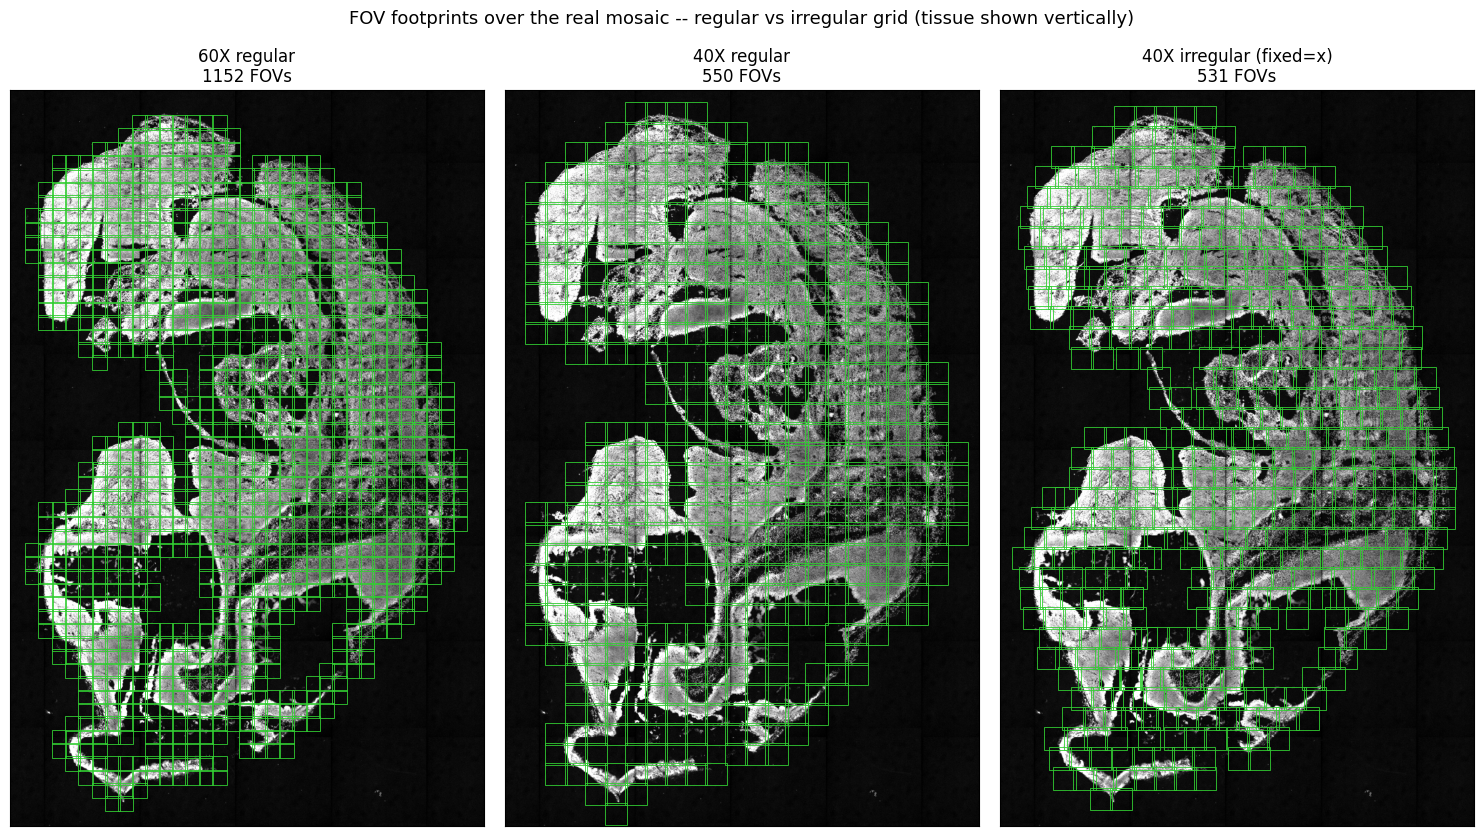

In [9]:
def _um_to_px_swapped(x, y):
    """Convert (x, y) stage microns to (plot_col, plot_row) canvas-pixel space,
    with X and Y swapped so the tissue displays with its long axis vertical."""
    plot_col = (np.asarray(y) - canvas.origin_um[1]) / canvas.pixel_size_um
    plot_row = (np.asarray(x) - canvas.origin_um[0]) / canvas.pixel_size_um
    return plot_col, plot_row

canvas_image_swapped = canvas.image.T   # swap rows/cols to match _um_to_px_swapped above
covered_vals = canvas.image[canvas.covered]
vmin, vmax = np.percentile(covered_vals, [1, 99])

# One shared crop (same tissue in all 3 panels) -- fair side-by-side comparison.
bx_min, by_min, bx_max, by_max = boundary_polygon.bounds
margin_um = 300.0
col_min, row_min = _um_to_px_swapped(bx_min - margin_um, by_min - margin_um)
col_max, row_max = _um_to_px_swapped(bx_max + margin_um, by_max + margin_um)
col_lo, col_hi = sorted([float(col_min), float(col_max)])
row_lo, row_hi = sorted([float(row_min), float(row_max)])

PANELS = [
    ("60X regular",   regular_results["60X"].coords,       geometry["60X"]["fov_size_um"]),
    ("40X regular",   regular_results["40X"].coords,       geo40["fov_size_um"]),
    (f"40X irregular (fixed={WINNER_AXIS})", winner["coords"], geo40["fov_size_um"]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
for ax, (label, coords, fov_size_um) in zip(axes, PANELS):
    half_px = (fov_size_um / 2.0) / canvas.pixel_size_um
    ax.imshow(canvas_image_swapped, cmap="gray", vmin=vmin, vmax=vmax, origin="upper")
    pc, pr = _um_to_px_swapped(coords[:, 0], coords[:, 1])
    for c, r in zip(pc, pr):
        ax.add_patch(mpatches.Rectangle(
            (c - half_px, r - half_px), 2 * half_px, 2 * half_px,
            lw=0.6, edgecolor="limegreen", facecolor="none"))
    ax.set_xlim(col_lo, col_hi); ax.set_ylim(row_hi, row_lo)   # row axis still increases downward
    ax.set_title(f"{label}\n{len(coords)} FOVs", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("FOV footprints over the real mosaic -- regular vs irregular grid (tissue shown vertically)", fontsize=13, y=1.04)
fig.tight_layout()
FIG_DIR = SAMPLE_DIR / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "compare_60x_40x_irregular_grid_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## FOV-count comparison across all 3 cases

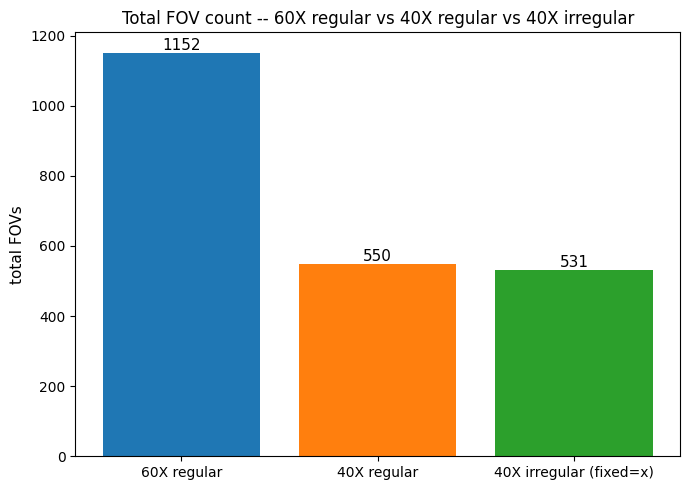

In [10]:
labels = [label for label, _, _ in PANELS]
counts = [len(coords) for _, coords, _ in PANELS]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts, color=["tab:blue", "tab:orange", "tab:green"])
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(n),
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("total FOVs", fontsize=11)
ax.set_title("Total FOV count -- 60X regular vs 40X regular vs 40X irregular", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "compare_60x_40x_irregular_grid_fov_counts.png", dpi=150)
plt.show()

## Takeaways

- The irregular grid (fixing one axis on a regular lattice, hugging the
  tissue's own local extent on the other) needs FEWER FOVs than the plain
  regular 40X grid on this real boundary -- see the comparison table above
  for the exact counts, and the printed cell above it for which axis
  (`fixed_axis='x'` vs `'y'`) won on this dataset.
- `coverage_fraction` in the comparison table shows whether tightening the
  grid to the tissue's local shape ever drops real tissue from the imaging
  plan -- checked directly rather than assumed, since `filter_scanning_path`'s
  own any-overlap acceptance rule is applied identically to every candidate
  coordinate regardless of which algorithm generated it.
- The single-connected-component constraint is enforced with an explicit
  `assert`, not just checked and reported -- if a future boundary ever
  breaks it for both axis choices, this notebook fails loudly instead of
  silently shipping an unstitchable grid.
- `bottleneck_overlap` quantifies exactly how much weaker the irregular
  grid's worst-case real overlap is than the regular grid's nominal, by-
  design value (`1 - NON_OVERLAP_FRACTION` = 10%): every irregular row/
  column is independently re-centred on its own local tissue extent, so
  adjacent rows/columns are no longer guaranteed to share the same lattice
  phase -- their cross-axis overlap is whatever coincidence of local
  centring leaves behind, not a designed margin. That is a real, measured
  trade-off of this approach, not a hypothetical one.
- This notebook only explores the irregular-grid *algorithm*; it lives
  entirely in this test notebook (not `acquisition/positions.py`) -- turning
  it into a production option would additionally need a real boustrophedon
  scan-path ordering (this notebook's per-row/column direction alternation
  is a rough stand-in) and a decision on where the connectivity margin
  found here is acceptable for real bead-based registration.